# Topology Enumeration and Synthesis

This notebook demonstrates how to **enumerate**, **catalog**, **synthesize**,
and **co-optimize** planar linkage topologies using pylinkage.

1. **Part A** enumerates all structurally distinct 1-DOF planar linkage
   topologies up to 8 links and validates the counts against published results.
2. **Part B** browses the built-in topology catalog.
3. **Part C** runs topology-aware synthesis to find the best mechanism
   (four-bar or six-bar) for a set of precision points.
4. **Part D** jointly optimizes topology *and* link dimensions using
   mixed-variable multi-objective optimization (requires `pymoo`).

In [1]:
import math

import matplotlib.pyplot as plt

from pylinkage.topology import (
    are_isomorphic,
    compute_dof,
    compute_mobility,
    enumerate_all,
    enumerate_topologies,
    load_catalog,
)

In [ ]:
from pylinkage.synthesis import (
    fourbar_from_lengths,
    stephenson_from_lengths,
    watt_from_lengths,
)


def plot_mechanism(ax, linkage, title="", iterations=200, n_ghost=5):
    """Simulate a linkage and draw trajectories + mechanism snapshots.

    Draws joint paths as thin colored lines and overlays the mechanism
    bars at several positions ("ghosts") through the cycle.
    """
    from pylinkage.components import Ground

    loci = list(linkage.step(iterations=iterations))
    if not loci:
        ax.text(0.5, 0.5, "No valid frames", transform=ax.transAxes, ha="center")
        return

    comps = linkage.components
    n_joints = len(comps)

    # Identify ground joints (no trajectory to draw)
    is_ground = [isinstance(c, Ground) for c in comps]

    # Color palette for joint paths
    path_colors = [
        "#2E86AB", "#A23B72", "#F18F01", "#3B9979",
        "#D64045", "#7B4B94", "#E8C547", "#1B998B",
    ]

    # Draw full-cycle trajectories for each moving joint
    for j in range(n_joints):
        if is_ground[j]:
            continue
        xs = [f[j][0] for f in loci if f[j][0] is not None]
        ys = [f[j][1] for f in loci if f[j][1] is not None]
        if xs:
            color = path_colors[j % len(path_colors)]
            ax.plot(xs, ys, "-", color=color, linewidth=1, alpha=0.4)

    # Build adjacency: which joints are connected?
    # For the component API: Ground has no parents,
    # Crank has .anchor, RRRDyad has .anchor1/.anchor2
    connections = []
    for j, comp in enumerate(comps):
        for attr in ("anchor", "anchor1", "anchor2"):
            parent = getattr(comp, attr, None)
            if parent is not None and parent in comps:
                p = comps.index(parent)
                connections.append((p, j))
            elif hasattr(parent, "_component") and parent._component in comps:
                p = comps.index(parent._component)
                connections.append((p, j))

    # Draw ghost mechanism at evenly spaced frames
    ghost_indices = [
        int(i * len(loci) / n_ghost) for i in range(n_ghost)
    ]
    for gi, fi in enumerate(ghost_indices):
        alpha = 0.15 + 0.15 * (gi / max(n_ghost - 1, 1))
        frame = loci[fi]
        for p, j in connections:
            if frame[p][0] is None or frame[j][0] is None:
                continue
            ax.plot(
                [frame[p][0], frame[j][0]],
                [frame[p][1], frame[j][1]],
                "-", color="#555555", linewidth=2, alpha=alpha,
            )

    # Draw mechanism bars at the initial position (bold)
    frame0 = loci[0]
    for p, j in connections:
        if frame0[p][0] is None or frame0[j][0] is None:
            continue
        color = path_colors[j % len(path_colors)]
        ax.plot(
            [frame0[p][0], frame0[j][0]],
            [frame0[p][1], frame0[j][1]],
            "-o", color=color, linewidth=3, markersize=5, zorder=4,
        )

    # Draw ground pivots
    for j, comp in enumerate(comps):
        if is_ground[j]:
            ax.plot(
                comp.x, comp.y, "ks", markersize=10, zorder=5,
            )

    # Label joints
    for j, comp in enumerate(comps):
        if frame0[j][0] is not None:
            ax.annotate(
                comp.name, (frame0[j][0], frame0[j][1]),
                textcoords="offset points", xytext=(5, 5),
                fontsize=8, fontweight="bold",
            )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

---
## Part A: Enumerating Linkage Topologies

A planar linkage **topology** describes how links and joints are connected,
without specifying any dimensions. Two topologies are *structurally distinct*
if no relabeling of links can make them identical (i.e., they are
non-isomorphic graphs).

For 1-DOF mechanisms with only revolute joints, published atlases
(Mruthyunjaya 1984) give:

| Links | Distinct topologies |
|------:|--------------------:|
|     4 |                   1 |
|     6 |                   2 |
|     8 |                  16 |

The `enumerate_topologies(n)` function generates all non-isomorphic
link-adjacency graphs with `n` links and DOF=1, then converts them
to `HypergraphLinkage` objects.

### 1. Four-bar topologies

In [3]:
topos_4 = enumerate_topologies(4)
print(f"4-link topologies found: {len(topos_4)}")
assert len(topos_4) == 1, f"Expected 1, got {len(topos_4)}"

# Verify DOF = 1
for i, topo in enumerate(topos_4):
    info = compute_mobility(topo)
    print(f"  Topology {i}: {info.num_links} links, {info.num_full_joints} joints, DOF={info.dof}")

4-link topologies found: 1
  Topology 0: 4 links, 4 joints, DOF=1


In [ ]:
fourbar = fourbar_from_lengths(
    crank_length=1.0, coupler_length=3.5,
    rocker_length=3.0, ground_length=4.0,
    initial_crank_angle=math.pi / 4,
    iterations=200,
)

fig, ax = plt.subplots(figsize=(7, 5))
plot_mechanism(ax, fourbar, title="Four-bar linkage (1 topology)")
plt.tight_layout()
plt.show()

### 2. Six-bar topologies (Watt and Stephenson)

In [5]:
topos_6 = enumerate_topologies(6)
print(f"6-link topologies found: {len(topos_6)}")
assert len(topos_6) == 2, f"Expected 2, got {len(topos_6)}"

for i, topo in enumerate(topos_6):
    info = compute_mobility(topo)
    print(f"  Topology {i}: {info.num_links} links, {info.num_full_joints} joints, DOF={info.dof}")

6-link topologies found: 2
  Topology 0: 6 links, 7 joints, DOF=1
  Topology 1: 6 links, 7 joints, DOF=1


The two six-bar topologies differ in how their ternary links connect.
The **Watt** chain has the second loop branching from the crank output,
while the **Stephenson** chain branches from the coupler (first dyad).
Below we build and simulate one example of each.

In [ ]:
watt = watt_from_lengths(
    crank=1.5, coupler1=4.0, rocker1=3.5,
    link4=3.0, link5=2.5, rocker2=3.0,
    ground_length=6.0,
    initial_crank_angle=math.pi / 4,
)
steph = stephenson_from_lengths(
    crank=1.2, coupler=4.0, rocker=3.0,
    link4=2.0, link5=3.0, link6=2.5,
    ground_length=5.0,
    initial_crank_angle=math.pi / 3,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_mechanism(ax1, watt, title="Watt six-bar")
plot_mechanism(ax2, steph, title="Stephenson six-bar")
fig.suptitle(
    "The two distinct six-bar topologies",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

### 3. Eight-bar topologies

In [7]:
topos_8 = enumerate_topologies(8)
print(f"8-link topologies found: {len(topos_8)}")
assert len(topos_8) == 16, f"Expected 16, got {len(topos_8)}"

# Verify all have DOF = 1
for i, topo in enumerate(topos_8):
    dof = compute_dof(topo)
    assert dof == 1, f"Topology {i} has DOF={dof}, expected 1"

print(f"All {len(topos_8)} eight-bar topologies verified: DOF=1.")

8-link topologies found: 16
All 16 eight-bar topologies verified: DOF=1.


With 8 links and 16 distinct topologies, constructing working examples
of each requires choosing compatible link lengths — a synthesis problem
in itself. The topology enumeration guarantees structural correctness;
dimensional synthesis (Part C and D) finds the actual dimensions.

### 4. Enumerate all at once with `enumerate_all`

In [9]:
all_topos = enumerate_all(max_links=8, dof=1)

print(f"{'Links':>6s}  {'Count':>6s}  {'Expected':>8s}  {'Status':>6s}")
print("=" * 32)
expected = {4: 1, 6: 2, 8: 16}
for n_links, topos in sorted(all_topos.items()):
    exp = expected[n_links]
    status = "PASS" if len(topos) == exp else "FAIL"
    print(f"{n_links:6d}  {len(topos):6d}  {exp:8d}  {status:>6s}")

total = sum(len(t) for t in all_topos.values())
print(f"\nTotal: {total} distinct 1-DOF topologies up to 8 links.")

 Links   Count  Expected  Status
     4       1         1    PASS
     6       2         2    PASS
     8      16        16    PASS

Total: 19 distinct 1-DOF topologies up to 8 links.


### 5. Isomorphism check: Watt vs Stephenson

The two six-bar topologies (Watt and Stephenson) are structurally different.
The `are_isomorphic` function confirms they are non-isomorphic, while
each topology is isomorphic to itself.

In [10]:
watt, stephenson = topos_6[0], topos_6[1]

print(f"Watt == Watt:           {are_isomorphic(watt, watt)}")
print(f"Stephenson == Stephenson: {are_isomorphic(stephenson, stephenson)}")
print(f"Watt == Stephenson:     {are_isomorphic(watt, stephenson)}")

assert are_isomorphic(watt, watt)
assert are_isomorphic(stephenson, stephenson)
assert not are_isomorphic(watt, stephenson)
print("\nIsomorphism checks passed: Watt and Stephenson are distinct topologies.")

Watt == Watt:           True
Stephenson == Stephenson: True
Watt == Stephenson:     False

Isomorphism checks passed: Watt and Stephenson are distinct topologies.


### 6. Structural details via `compute_mobility`

In [11]:
print(f"{'Topology':>15s}  {'Links':>5s}  {'J1':>4s}  {'J2':>4s}  {'DOF':>4s}")
print("=" * 38)

labels = {
    4: ["Four-bar"],
    6: ["Watt", "Stephenson"],
}

for n_links in [4, 6]:
    for i, topo in enumerate(all_topos[n_links]):
        info = compute_mobility(topo)
        label = labels[n_links][i]
        print(
            f"{label:>15s}  {info.num_links:5d}  "
            f"{info.num_full_joints:4d}  {info.num_half_joints:4d}  {info.dof:4d}"
        )

print("\nAll six-bar topologies have 6 links, 7 joints, and DOF=1.")

       Topology  Links    J1    J2   DOF
       Four-bar      4     4     0     1
           Watt      6     7     0     1
     Stephenson      6     7     0     1

All six-bar topologies have 6 links, 7 joints, and DOF=1.


---
## Part B: Topology Catalog

pylinkage ships a built-in catalog of all 19 topologies (1 four-bar + 2
six-bars + 16 eight-bars). Each entry has metadata including the human-readable
name, link assortment (degree sequence), and Assur group decomposition.

In [12]:
catalog = load_catalog()
print(f"Catalog contains {len(catalog)} topologies.\n")

# Browse by family
for family in ["four-bar", "six-bar", "eight-bar"]:
    entries = catalog.by_family(family)
    print(f"--- {family} family ({len(entries)} entries) ---")
    for entry in entries:
        print(
            f"  {entry.id:20s}  name={entry.name!r:30s}  "
            f"links={entry.num_links}  joints={entry.num_joints}  "
            f"assortment={entry.link_assortment}"
        )
    print()

Catalog contains 19 topologies.

--- four-bar family (1 entries) ---
  four-bar              name='Four-bar linkage'              links=4  joints=4  assortment=(2, 2, 2, 3)

--- six-bar family (2 entries) ---
  watt                  name='Watt six-bar'                  links=6  joints=7  assortment=(2, 2, 2, 3, 3, 3)
  stephenson            name='Stephenson six-bar'            links=6  joints=7  assortment=(2, 2, 2, 3, 3, 3)

--- eight-bar family (16 entries) ---
  eight-bar-01          name='Eight-bar type 1'              links=8  joints=10  assortment=(2, 2, 2, 2, 2, 3, 4, 4)
  eight-bar-02          name='Eight-bar type 2'              links=8  joints=10  assortment=(2, 2, 2, 2, 2, 3, 4, 4)
  eight-bar-03          name='Eight-bar type 3'              links=8  joints=10  assortment=(2, 2, 2, 2, 3, 3, 3, 4)
  eight-bar-04          name='Eight-bar type 4'              links=8  joints=10  assortment=(2, 2, 2, 2, 3, 3, 3, 4)
  eight-bar-05          name='Eight-bar type 5'              lin

### 7. Catalog entry attributes

Each `CatalogEntry` stores the topology graph, link assortment (sorted
degree sequence), and Assur group decomposition (if available).

In [13]:
# Inspect a specific topology
watt_entry = catalog.get("watt")
stephenson_entry = catalog.get("stephenson")

for entry in [watt_entry, stephenson_entry]:
    if entry is None:
        continue
    print(f"ID:              {entry.id}")
    print(f"Name:            {entry.name}")
    print(f"Family:          {entry.family}")
    print(f"Links:           {entry.num_links}")
    print(f"Joints:          {entry.num_joints}")
    print(f"DOF:             {entry.dof}")
    print(f"Link assortment: {entry.link_assortment}")
    print(f"Assur groups:    {entry.assur_groups}")
    print()

ID:              watt
Name:            Watt six-bar
Family:          six-bar
Links:           6
Joints:          7
DOF:             1
Link assortment: (2, 2, 2, 3, 3, 3)
Assur groups:    ('RRR', 'RRR', 'RRR', 'RRR')

ID:              stephenson
Name:            Stephenson six-bar
Family:          six-bar
Links:           6
Joints:          7
DOF:             1
Link assortment: (2, 2, 2, 3, 3, 3)
Assur groups:    ('RRRRRR',)



### 8. Catalog entries match enumerated topologies

We verify that the catalog entries are isomorphic to the enumerated topologies.

In [14]:
catalog_4 = catalog.by_num_links(4)
catalog_6 = catalog.by_num_links(6)

# Four-bar: single topology, should match
assert len(catalog_4) == 1
g_catalog = catalog_4[0].to_graph()
g_enum = topos_4[0]
print(f"Four-bar catalog vs enumerated: isomorphic = {are_isomorphic(g_catalog, g_enum)}")

# Six-bar: two topologies; each catalog entry should match one enumerated topology
assert len(catalog_6) == 2
matched = 0
for cat_entry in catalog_6:
    g_cat = cat_entry.to_graph()
    for g_en in topos_6:
        if are_isomorphic(g_cat, g_en):
            print(f"Catalog '{cat_entry.id}' matches an enumerated six-bar topology.")
            matched += 1
            break

assert matched == 2, f"Expected 2 matches, got {matched}"
print("\nAll catalog entries matched to enumerated topologies.")

Four-bar catalog vs enumerated: isomorphic = True
Catalog 'watt' matches an enumerated six-bar topology.
Catalog 'stephenson' matches an enumerated six-bar topology.

All catalog entries matched to enumerated topologies.


---
## Part C: Topology-Aware Synthesis

Given a set of precision points that a coupler curve should pass through,
`synthesize()` (aliased as `multi_topology_synthesize` in the package)
tries every topology from the catalog and returns solutions ranked by
quality metrics (path accuracy, transmission angle, link ratios, etc.).

We define five precision points forming an arc and search for solutions
using topologies up to 6 links.

In [15]:
from pylinkage.synthesis import TopologySolution, multi_topology_synthesize

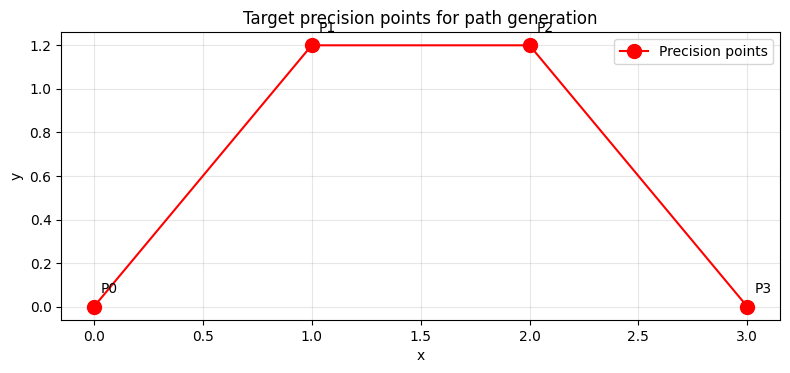

In [16]:
# Define precision points: an arc-like curve
precision_points = [
    (0.0, 0.0),
    (1.0, 1.2),
    (2.0, 1.2),
    (3.0, 0.0),
]

# Visualize the target points
fig, ax = plt.subplots(figsize=(8, 4))
px, py = zip(*precision_points, strict=False)
ax.plot(px, py, 'ro-', markersize=10, linewidth=1.5, label='Precision points')
for i, (x, y) in enumerate(precision_points):
    ax.annotate(f'P{i}', (x, y), textcoords='offset points',
                xytext=(5, 10), fontsize=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Target precision points for path generation')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Run multi-topology synthesis

We search across four-bar and six-bar topologies. The function ranks
solutions by a weighted composite score (lower is better).

In [17]:
solutions = multi_topology_synthesize(
    precision_points,
    max_links=6,
    max_solutions_per_topology=5,
    max_total_solutions=10,
)

print(f"Found {len(solutions)} solutions.\n")

if solutions:
    print(f"{'Rank':>4s}  {'Topology':>15s}  {'Score':>8s}  {'Accuracy':>10s}  "
          f"{'Trans. Angle':>12s}  {'Link Ratio':>10s}  {'Grashof':>7s}")
    print("=" * 80)
    for rank, sol in enumerate(solutions, 1):
        m = sol.metrics
        print(
            f"{rank:4d}  {sol.topology_entry.name:>15s}  "
            f"{m.overall_score:8.4f}  {m.path_accuracy:10.4f}  "
            f"{m.min_transmission_angle:12.1f}  {m.link_ratio:10.2f}  "
            f"{'Yes' if m.is_grashof else 'No':>7s}"
        )
else:
    print("No solutions found. This can happen if the precision points")
    print("are geometrically incompatible with the available topologies.")

Found 10 solutions.

Rank         Topology     Score    Accuracy  Trans. Angle  Link Ratio  Grashof
   1  Four-bar linkage    0.2748      0.0177           4.9        3.04      Yes
   2  Four-bar linkage    0.2889      0.0337           4.1        3.08      Yes
   3  Four-bar linkage    0.2970      0.0083           3.4        4.50      Yes
   4  Four-bar linkage    0.2997      0.0107           2.5        4.52      Yes
   5  Four-bar linkage    0.3053      0.0167           1.3        4.75      Yes
   6  Four-bar linkage    0.3066      0.0266           2.9        4.13      Yes
   7  Four-bar linkage    0.3115      0.0563           3.1        4.46      Yes
   8  Four-bar linkage    0.3179      0.0110           2.4        5.89      Yes
   9  Four-bar linkage    0.3203      0.0069           1.9        5.98      Yes
  10  Four-bar linkage    0.3505      0.0754           7.3        9.62      Yes


### 10. Visualize the best solution

We simulate the best-ranked linkage and plot the coupler curve against
the target precision points, drawing the mechanism bars at one position.

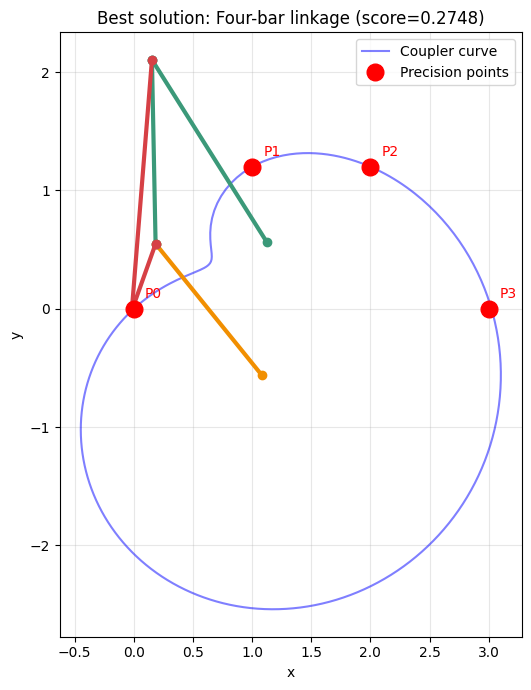

In [18]:
if solutions:
    best = solutions[0]
    linkage = best.linkage

    fig, ax = plt.subplots(figsize=(10, 7))

    # Simulate the linkage
    initial_coords = linkage.get_coords()
    all_positions = list(linkage.step())
    linkage.set_coords(initial_coords)

    if all_positions:
        n_joints = len(all_positions[0])

        # Draw coupler curve (last joint by default)
        coupler_idx = n_joints - 1
        coupler_path = [
            (pos[coupler_idx][0], pos[coupler_idx][1])
            for pos in all_positions
            if pos[coupler_idx][0] is not None
        ]
        if coupler_path:
            cpx, cpy = zip(*coupler_path, strict=False)
            ax.plot(cpx, cpy, 'b-', linewidth=1.5, alpha=0.5, label='Coupler curve')

        # Draw mechanism bars at initial position
        pos0 = all_positions[0]
        link_colors = ['#2E86AB', '#A23B72', '#F18F01', '#3B9979', '#D64045', '#7B4B94']
        for j_idx in range(n_joints):
            joint = linkage.joints[j_idx]
            # Draw connection to parent joints
            for attr in ['joint0', 'joint1']:
                parent = getattr(joint, attr, None)
                if parent is not None and parent in linkage.joints:
                    p_idx = linkage.joints.index(parent)
                    if pos0[j_idx][0] is not None and pos0[p_idx][0] is not None:
                        color = link_colors[j_idx % len(link_colors)]
                        ax.plot(
                            [pos0[p_idx][0], pos0[j_idx][0]],
                            [pos0[p_idx][1], pos0[j_idx][1]],
                            '-o', color=color, linewidth=3, markersize=6,
                        )

        # Draw ground pivots
        for j_idx in range(n_joints):
            joint = linkage.joints[j_idx]
            if hasattr(joint, 'x') and hasattr(joint, 'y') and not hasattr(joint, 'joint0'):
                ax.plot(joint.x, joint.y, 'ks', markersize=10, zorder=5)

    # Plot precision points
    ppx, ppy = zip(*precision_points, strict=False)
    ax.plot(ppx, ppy, 'ro', markersize=12, zorder=10, label='Precision points')
    for i, (x, y) in enumerate(precision_points):
        ax.annotate(f'P{i}', (x, y), textcoords='offset points',
                    xytext=(8, 8), fontsize=10, color='red')

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(
        f'Best solution: {best.topology_entry.name} '
        f'(score={best.metrics.overall_score:.4f})'
    )
    ax.set_aspect('equal')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No solutions to visualize.")

### 11. Compare four-bar vs six-bar solutions

If solutions from different topologies were found, we compare their
quality metrics side-by-side.

In [19]:
if solutions:
    # Group solutions by family
    by_family: dict[str, list[TopologySolution]] = {}
    for sol in solutions:
        fam = sol.topology_entry.family
        by_family.setdefault(fam, []).append(sol)

    print("Solutions by topology family:")
    for fam, sols in sorted(by_family.items()):
        best_sol = sols[0]
        print(
            f"  {fam:12s}: {len(sols)} solution(s), "
            f"best score = {best_sol.metrics.overall_score:.4f}, "
            f"accuracy = {best_sol.metrics.path_accuracy:.4f}"
        )

    if len(by_family) > 1:
        print("\nMultiple topology families found -- the synthesis explored")
        print("both four-bar and six-bar design spaces.")
    else:
        print(f"\nAll solutions use the {list(by_family.keys())[0]} topology.")
else:
    print("No solutions to compare.")

Solutions by topology family:
  four-bar    : 10 solution(s), best score = 0.2748, accuracy = 0.0177

All solutions use the four-bar topology.


---
## Part D: Co-Optimization (Topology + Dimensions)

Standard synthesis fixes the topology first, then solves for dimensions.
**Co-optimization** searches both spaces simultaneously: the optimizer
chooses which topology to use AND what link lengths to assign, treating
the topology index as a discrete variable alongside continuous dimensions.

This uses NSGA-II with custom mixed-variable genetic operators and
requires the `pymoo` package.

We define two objectives:
- **Path accuracy**: RMS error of the coupler curve vs. precision points (minimize).
- **Compactness**: Bounding box area of the mechanism trajectory (minimize).

In [20]:
from pylinkage.optimization import (
    CoOptimizationConfig,
    co_optimize,
)
from pylinkage.synthesis.ranking import compute_compactness, compute_path_accuracy

In [21]:
# Define objectives as callables (linkage) -> float
# Both are minimized.
target_points = precision_points  # reuse from Part C


def accuracy_objective(linkage):
    """RMS coupler path error vs target points."""
    return compute_path_accuracy(linkage, target_points)


def compactness_objective(linkage):
    """Bounding box area of mechanism trajectory."""
    return compute_compactness(linkage)

### 12. Run co-optimization

We use modest settings (50 generations, population of 30, only up to
6 links) to keep runtime reasonable. Production runs would use more
generations and include eight-bar topologies.

In [22]:
try:
    config = CoOptimizationConfig(
        max_links=6,
        n_generations=50,
        pop_size=30,
        algorithm="nsga2",
        seed=42,
        verbose=False,
    )

    result = co_optimize(
        objectives=[accuracy_objective, compactness_objective],
        precision_points=target_points,
        config=config,
        objective_names=["Path Error", "Compactness"],
    )

    print("Co-optimization completed.")
    print(f"  Total evaluations: {result.n_evaluations}")
    print(f"  Pareto front size: {len(result.pareto_front)}")
    print(f"  Solutions found:   {len(result.solutions)}")

except ImportError:
    result = None
    print("pymoo is not installed. Install it with:")
    print("  pip install pylinkage[moo]")
    print("\nSkipping co-optimization demo.")

/home/h/Documents/dev/hu/the-great-walker/pylinkage/.venv/lib/python3.11/site-packages/pymoo/operators/survival/rank_and_crowding/metrics.py:97: RuntimeWarning: invalid value encountered in subtract
  dist = np.vstack([F, np.full(n_obj, np.inf)]) - np.vstack([np.full(n_obj, -np.inf), F])
/home/h/Documents/dev/hu/the-great-walker/pylinkage/.venv/lib/python3.11/site-packages/pymoo/operators/survival/rank_and_crowding/metrics.py:100: RuntimeWarning: invalid value encountered in subtract
  norm = np.max(F, axis=0) - np.min(F, axis=0)


Co-optimization completed.
  Total evaluations: 1500
  Pareto front size: 30
  Solutions found:   30


### 13. Analyze the Pareto front

Each solution on the Pareto front represents a different trade-off
between path accuracy and compactness. We examine which topologies
appear on the front.

In [23]:
if result is not None and result.solutions:
    # Count topologies on the Pareto front
    topo_counts: dict[str, int] = {}
    for sol in result.solutions:
        name = sol.topology_entry.name if sol.topology_entry else "unknown"
        topo_counts[name] = topo_counts.get(name, 0) + 1

    print("Topologies on the Pareto front:")
    for name, count in sorted(topo_counts.items(), key=lambda x: -x[1]):
        print(f"  {name:25s}: {count} solution(s)")

    # Print detailed results for up to 5 solutions
    print(f"\n{'Rank':>4s}  {'Topology':>20s}  {'Path Error':>10s}  {'Compactness':>11s}")
    print("=" * 55)
    for i, sol in enumerate(result.solutions[:5]):
        name = sol.topology_entry.name if sol.topology_entry else "unknown"
        print(f"{i+1:4d}  {name:>20s}  {sol.scores[0]:10.4f}  {sol.scores[1]:11.4f}")
elif result is not None:
    print("No feasible solutions found on the Pareto front.")
    print("This can happen with very few generations or restrictive precision points.")
else:
    print("Co-optimization was skipped (pymoo not available).")

Topologies on the Pareto front:
  Watt six-bar             : 30 solution(s)

Rank              Topology  Path Error  Compactness
   1          Watt six-bar      1.6573       0.9998
   2          Watt six-bar      1.1177      11.8956
   3          Watt six-bar      1.6573       0.9998
   4          Watt six-bar      1.1177      11.8956
   5          Watt six-bar      1.1941       6.7948


### 14. Plot the Pareto front

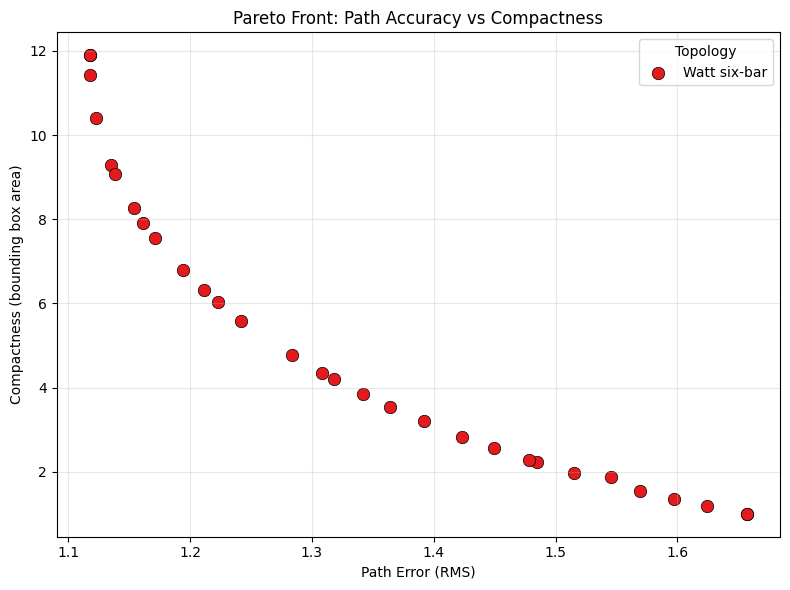

In [24]:
if result is not None and result.solutions:
    fig, ax = plt.subplots(figsize=(8, 6))

    # Color-code by topology
    topo_names = list(topo_counts.keys())
    cmap = plt.cm.Set1
    color_map = {name: cmap(i / max(len(topo_names), 1)) for i, name in enumerate(topo_names)}

    for sol in result.solutions:
        name = sol.topology_entry.name if sol.topology_entry else "unknown"
        ax.scatter(
            sol.scores[0], sol.scores[1],
            color=color_map.get(name, 'gray'),
            s=80, edgecolors='black', linewidths=0.5,
            label=name,
        )

    # De-duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles, strict=False))
    ax.legend(unique.values(), unique.keys(), title='Topology')

    ax.set_xlabel('Path Error (RMS)')
    ax.set_ylabel('Compactness (bounding box area)')
    ax.set_title('Pareto Front: Path Accuracy vs Compactness')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No Pareto front to plot.")

---
## Summary

**Topology enumeration** (Part A):
- `enumerate_topologies(n)` generates all non-isomorphic 1-DOF planar
  linkage topologies with `n` links.
- Results match published atlases: 1 four-bar, 2 six-bars, 16 eight-bars.
- `compute_dof()` and `compute_mobility()` verify the structural properties.
- `are_isomorphic()` confirms Watt and Stephenson are distinct.

**Topology catalog** (Part B):
- `load_catalog()` provides all 19 topologies with metadata.
- Entries include link assortment, Assur group decomposition, and the
  serialized `HypergraphLinkage` graph.
- Catalog entries are verified to be isomorphic to the enumerated topologies.

**Topology-aware synthesis** (Part C):
- `multi_topology_synthesize()` searches across all compatible topologies
  for the best linkage matching given precision points.
- Solutions are ranked by a weighted composite of path accuracy,
  transmission angle, link ratio, compactness, and simplicity.

**Co-optimization** (Part D):
- `co_optimize()` jointly searches discrete topology space and continuous
  dimensional space using NSGA-II with mixed-variable operators.
- The Pareto front reveals trade-offs between competing objectives
  and which topologies are most effective for each trade-off region.